In [1]:
!pip install --upgrade pip
!pip install numpy
!pip install tensorflow keras

type(images)=<class 'numpy.ndarray'>, type(labels)=<class 'numpy.ndarray'>
images.shape=(1000, 784), labels.shape=(1000,)
weights_0_1.shape=(784, 40), weights_1_2.shape=(40, 10)
 I:0 Train-Err:0.895 Train-Acc:0.279 Test-Err:0.728 Test-Acc:0.5118
 I:1 Train-Err:0.729 Train-Acc:0.471 Test-Err:0.639 Test-Acc:0.5872
 I:2 Train-Err:0.671 Train-Acc:0.544 Test-Err:0.579 Test-Acc:0.6547
 I:3 Train-Err:0.621 Train-Acc:0.577 Test-Err:0.544 Test-Acc:0.6692
 I:4 Train-Err:0.593 Train-Acc:0.598 Test-Err:0.516 Test-Acc:0.7053
 I:5 Train-Err:0.582 Train-Acc:0.607 Test-Err:0.501 Test-Acc:0.7244
 I:6 Train-Err:0.543 Train-Acc:0.668 Test-Err:0.481 Test-Acc:0.7309
 I:7 Train-Err:0.537 Train-Acc:0.662 Test-Err:0.468 Test-Acc:0.7605
 I:8 Train-Err:0.523 Train-Acc:0.682 Test-Err:0.458 Test-Acc:0.7678
 I:9 Train-Err:0.518 Train-Acc:0.678 Test-Err:0.437 Test-Acc:0.768
 I:10 Train-Err:0.489 Train-Acc:0.72 Test-Err:0.436 Test-Acc:0.7854
 I:11 Train-Err:0.491 Train-Acc:0.713 Test-Err:0.428 Test-Acc:0.784
 I:12 T

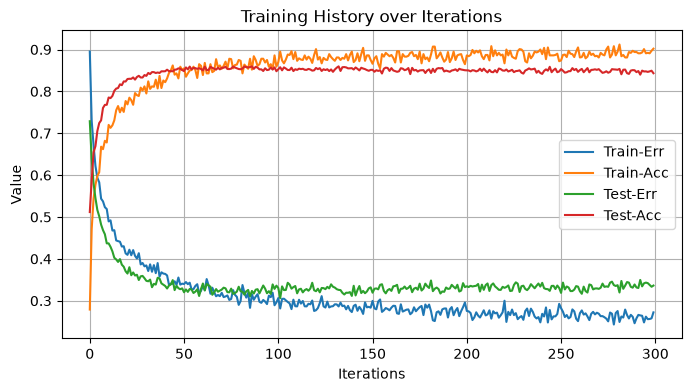

In [ ]:
import sys, numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()
# 255 is the maximum value of a pixel in an image. Dividing by 255 normalizes the pixel values to be between 0 and 1.
# each deata point is an pixel that has a value between 0 and 255, where 0 is black and 255 is white. By dividing by 255, we scale the pixel values to be between 0 and 1, which is a common practice in machine learning to improve convergence during training.
images, labels = (x_train[0:1000].reshape(1000, 28 * 28) / 255,
                  y_train[0:1000])
print(f"type(images)={type(images)}, type(labels)={type(labels)}")
print(f"images.shape={images.shape}, labels.shape={labels.shape}")

# 0,1,2,3,..,9
# 1000x10 matrix
one_hot_labels = np.zeros((len(labels), 10))
for i, label in enumerate(labels):
    one_hot_labels[i][label] = 1

# Goal Prediction: 0,1,2,3,..,9
labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255
test_labels = np.zeros((len(y_test), 10))
for i, label in enumerate(y_test):
    test_labels[i][label] = 1


def relu(x):
    return (x > 0) * x

def relu2derive(output):
    return output > 0

np.random.seed(1)

alpha, iterations, hidden_size = (0.005, 300, 40)
# 28x28 = 784
pixels_per_image, num_labels = (784, 10)



# -0.1 to 0.1
# 784x40 matrix
weights_0_1 = 0.2 * np.random.random((pixels_per_image, hidden_size)) - 0.1
# 40x10 matrix
weights_1_2 = 0.2 * np.random.random((hidden_size , num_labels)) - 0.1

print(f"weights_0_1.shape={weights_0_1.shape}, weights_1_2.shape={weights_1_2.shape}")
# print(f"weights_0_1=\n{weights_0_1}\nweights_1_2=\n{weights_1_2}")

# matlab
train_error = []
train_accuracy = []
test_error = []
test_accuracy = []

for j in range(iterations):
    train_err, train_acc = (0.0, 0)

    for i in range(len(images)):
        # input layer is 1x784
        layer_0 = images[i:i+1]
        # hidden layer is 1x40
        ## 1x784 * 783x40 = 1x40
        layer_1 = relu(np.dot(layer_0, weights_0_1))

        # fill out 0 or 1 randomly for each element in dropou_mask , which has the same shape as layeer_1.
        # 0: disabled (dropout)
        # 1: enabled
        # dropout rate is 0.5 (50%)
        dropout_mask = np.random.randint(2, size=layer_1.shape)
        # retain the same expected value of the output by scaling the enabled neurons by 2 (1 / (1 - dropout_rate) = 1 / (1 - 0.5) = 2)
        layer_1 *= dropout_mask * 2

        # prediction layer is 1x10
        # 1x40 * 40x10 = 1x10
        layer_2 = np.dot(layer_1, weights_1_2)

        goal_prediction = labels[i:i+1]

        train_err += np.sum((layer_2 - goal_prediction) ** 2)
        # argmax returns the index of the maximum value in an array.
        # In this case, it is used to determine the predicted class (the index of the highest value in layer_2) and compare it to the actual class (the index of the highest value in goal_prediction).
        # If they match, it means the prediction was correct, and we increment train_acc by 1.
        train_acc += int(np.argmax(layer_2) == np.argmax(goal_prediction))

        layer_2_delta = layer_2 - goal_prediction
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2derive(layer_1)
        layer_1_delta *= dropout_mask

        weights_1_2 = weights_1_2 - alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 = weights_0_1 - alpha * layer_0.T.dot(layer_1_delta)

    # str()[0:5] is used to limit the number of characters displayed for the training error, making the output more concise and easier to read. It effectively truncates the string representation of the training error to the first 5 characters, which typically includes the most significant digits.
    # print("Train-Err=" + str(train_err / float(len(images)))[0:5])
    #train_error.append(train_err / float(len(images)))
    #train_accuracy.append(train_acc / float(len(images)))

    sys.stdout.write(
        " I:" + str(j) + \
        " Train-Err:" + str(train_err / float(len(images)))[0:5] + \
        " Train-Acc:" + str(train_acc / float(len(images)))
    )

#    if( j % 10 == 0 or j == iterations - 1):
    test_err, test_acc = (0.0, 0)

    for i in range(len(test_images)):
        layer_0 = test_images[i:i+1]
        layer_1 = relu(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)

        test_err += np.sum((layer_2 - test_labels[i:i+1]) ** 2)
        test_acc += int(np.argmax(layer_2) == np.argmax(test_labels[i:i+1]))

    sys.stdout.write(
        " Test-Err:" + str(test_err / float(len(test_images)))[0:5] + \
        " Test-Acc:" + str(test_acc / float(len(test_images)))
    )
    sys.stdout.write("\n")

    # matplotlib
    train_error.append(train_err / float(len(images)))
    train_accuracy.append(train_acc / float(len(images)))
    test_error.append(test_err / float(len(test_images)))
    test_accuracy.append(test_acc / float(len(test_images)))

plt.figure(figsize=(8, 4))
plt.plot(train_error, label="Train-Err")
plt.plot(train_accuracy, label="Train-Acc")
plt.plot(test_error, label="Test-Err")
plt.plot(test_accuracy, label="Test-Acc")
plt.xlabel("Iterations")
plt.ylabel("Value")
plt.title("Training History over Iterations")
plt.legend()
plt.grid(True)
plt.show()

